## Section 1.2: Elements of Linear Algebra
**Topics:** Linear spaces, Orthogonality, Gram–Schmidt process, Eigenvalues and Eigenvectors

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1suJ1xC1IlC31RKnk3qnMyhXJlhVljwIZ?usp=sharing)

In [14]:
# Import Necessary Packages
import numpy as np
import matplotlib.pyplot as plt
# Formatting and Spacing:
np.set_printoptions(formatter={'int': str})

## Section 1.2.1. Linear spaces
Linear spaces, also known as vector spaces, are non-empty sets closed under scalar multiplication and addition. To demonstrate how linear spaces work, this example will provide three vectors, a, b, and c such that a,b,c ∈ ℝ, and two constants d1 and d2 to show how a linear space may be applied.

In [15]:
print("LINEAR SPACES\n")
# 3 Vectors (a, b, c) and two constants (d1, d2)
a = np.array([3, 8, 2], dtype=int)
b = np.array([6, 8, 10], dtype=int)
c = np.array([40, 80, 120], dtype=int)
d1 = 10000
d2 = 0.5

# Identify each vector:
print("3 Vectors (a, b, c)")
print(f"a: {a}")
print(f"b: {b}")
print(f"c: {c}\n")

# Example of Linear Space applications:
print("Examples:")
print(f"1) a + b = {a} + {b} = {a + b}")
print(f"2) a + (b + c) = {a} + ({b} + {c}) = {a} + {b + c} = {a + (b + c)}")
print(f"3) a + {np.zeros_like(a)} = {a} + {np.zeros_like(a)} = {a + np.zeros_like(a)}")
print(f"4) {a} + {(-a)} = {a + (-a)}")
print(f"5) (d1 * d2) * a: ({d1} * {d2}) * {a} = ({d1 * d2}) * {a} = {(d1 * d2) * a}")
print(f"6) 10 * a - 6 * b + 3 * c = 10 * {a} - 6 * {b} + 3 * {c} = {10 * a} - {6 * b} + {3 * c} = {10 * a - 6 * b + 3 * c}")
print(f"7) a · (b + c) = {a @ (b + c)}, (a · b) + (a · c) = {(a @ b) + (a @ c)}, a · (b + c) == (a · b) + (a · c)")
print(f"8) 1 * v = v: 1 * a = {1} * {a} = {1 * a}")

LINEAR SPACES

3 Vectors (a, b, c)
a: [3 8 2]
b: [6 8 10]
c: [40 80 120]

Examples:
1) a + b = [3 8 2] + [6 8 10] = [9 16 12]
2) a + (b + c) = [3 8 2] + ([6 8 10] + [40 80 120]) = [3 8 2] + [46 88 130] = [49 96 132]
3) a + [0 0 0] = [3 8 2] + [0 0 0] = [3 8 2]
4) [3 8 2] + [-3 -8 -2] = [0 0 0]
5) (d1 * d2) * a: (10000 * 0.5) * [3 8 2] = (5000.0) * [3 8 2] = [15000. 40000. 10000.]
6) 10 * a - 6 * b + 3 * c = 10 * [3 8 2] - 6 * [6 8 10] + 3 * [40 80 120] = [30 80 20] - [36 48 60] + [120 240 360] = [114 272 320]
7) a · (b + c) = 1102, (a · b) + (a · c) = 1102, a · (b + c) == (a · b) + (a · c)
8) 1 * v = v: 1 * a = 1 * [3 8 2] = [3 8 2]


In this specific example, we determine if a 1x3 vector is still in the vector space by multiplying this vector by a scalar factor, and checking if it spans the vector space. The values on the vector are randomized 1 through 10, and the scaling factor is randomized 1 through 20.

In [21]:
# 3 Random integer values of a, b, and c. These will be used for the vector.
a = np.random.randint(1,10)
b = np.random.randint(1,10)
c = np.random.randint(1,10)

# Setting v as the vector, and setting the scaling factor to a random integer between 1 through 20.
v = np.array([[a,b,c]], dtype=float)
scaling_factor = np.random.randint(1, 20)

# Output the scaling factor, modified vector, and checking whether the modified vector is still in the vector space.
print(f"Scaling Factor: {scaling_factor}")
print(f"{scaling_factor}v = {scaling_factor * v}")
print(f"Is {scaling_factor}v lie within the subspace spanned by v? {np.isclose(np.linalg.norm(scaling_factor * v), scaling_factor * np.linalg.norm(v))}.")

Scaling Factor: 11
11v = [[11. 33. 44.]]
Is 11v lie within the subspace spanned by v? True.


## Section 1.2.2. Orthogonality


To prove orthogonality exists between two vectors, their dot product must equal zero. When their dot product is zero, the angle between the vectors should equal 90 degrees, forming a right angle with respect to the vectors. Additionally, the projection of x onto y is zero when the dot product equals zero. This example proves to determine if two vectors, x and y, are orthogonal.

The dot product of vectors x and y is 0.0.
The angle between x and y is 90.0 degrees.
The projection of x on y is [ 0. -0. -0.].


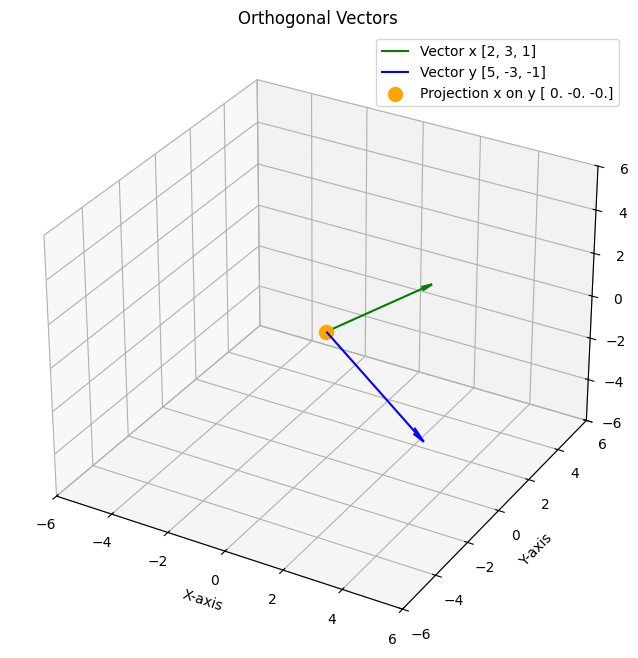

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2, 3, 1], dtype=float)
y = np.array([5, -3, -1], dtype=float)

# Calculate dot product, angle, and projection
dot_xy = np.dot(x, y)
norm_x = np.linalg.norm(x)
norm_y = np.linalg.norm(y)

angle_rad = np.arccos(np.clip(dot_xy / (norm_x * norm_y), -1.0, 1.0))
angle_between_x_and_y = np.degrees(angle_rad)

proj_xony = (dot_xy / np.dot(y, y)) * y

print(f"The dot product of vectors x and y is {dot_xy:.1f}.")
print(f"The angle between x and y is {angle_between_x_and_y:.1f} degrees.")
print(f"The projection of x on y is {np.round(proj_xony, 2)}.")

# 3D Vector Plot
fig = plt.figure(figsize=(8, 8))
ortho = fig.add_subplot(projection='3d')

o = [0, 0, 0]

# Plot vectors
ortho.quiver(*o, *x, color='g', label='Vector x [2, 3, 1]', arrow_length_ratio=0.1)
ortho.quiver(*o, *y, color='b', label='Vector y [5, -3, -1]', arrow_length_ratio=0.1)
ortho.scatter(proj_xony[0], proj_xony[1], proj_xony[2], color='orange', s=100, label=f"Projection x on y {proj_xony}")

# Plot limits for vector representation
ortho.set_xlim([-6, 6])
ortho.set_ylim([-6, 6])
ortho.set_zlim([-6, 6])

ortho.set_xlabel('X-axis')
ortho.set_ylabel('Y-axis')
ortho.set_zlabel('Z-axis')
ortho.legend()
plt.title("Orthogonal Vectors")

plt.show()



## Section 1.2.3: Gram-Schmidt


The Gram-Schmidt Process uses a linearly independent set of vectors within the same span to determine if a basis is orthonormal. This example provides a 4x4 matrix to show if it is close to the identity matrix.

In [18]:
# Define the Gram Schmidt Concept:
def gram_schmidt(col):
    vec = np.asarray(col)
    n, k = col.shape
    U = np.zeros((n, k))
    for i in range(k):
        U[:, i] = vec[:, i]
        for j in range(i):
            U[:, i] -= np.dot(U[:, j], U[:, i]) * U[:, j]
        U[:, i] /= np.linalg.norm(U[:, i])
    return U

# Set a 4x4 matrix:
A_gs = np.array(
    [
        [10, 20, 40, 1],
        [30, 80, 90, 17],
        [29, 61, 72, 43],
        [25, 64, 97, 80]
    ],
    dtype=float
)

# Print out Orthonormal vector of Q, identity matrix, and whether the matrix is close to the identity matrix:
Q = gram_schmidt(A_gs)
print(f"Original column vectors of A are\n{A_gs}")
print(f"\nOrthonormal basis of Q is\n{Q}")
print("\nThe identity matrix, Q.T @ Q, is")
print(Q.T @ Q)
print("\nAll close to identity?", np.allclose(Q.T @ Q, np.eye(4)))

Original column vectors of A are
[[10. 20. 40.  1.]
 [30. 80. 90. 17.]
 [29. 61. 72. 43.]
 [25. 64. 97. 80.]]

Orthonormal basis of Q is
[[ 0.20137403 -0.32355113  0.54180839 -0.7491374 ]
 [ 0.60412209  0.56816451 -0.41006246 -0.37957129]
 [ 0.58398469 -0.70747558 -0.32827242  0.22511641]
 [ 0.50343508  0.26829471  0.6561476   0.49400546]]

The identity matrix, Q.T @ Q, is
[[ 1.00000000e+00 -1.07648909e-15  2.57723349e-16 -5.10474885e-16]
 [-1.07648909e-15  1.00000000e+00  4.90098131e-17  3.60395341e-17]
 [ 2.57723349e-16  4.90098131e-17  1.00000000e+00  2.50831035e-17]
 [-5.10474885e-16  3.60395341e-17  2.50831035e-17  1.00000000e+00]]

All close to identity? True


In this specific example, we check for linear independence of three vectors, x, y, and z.

In [19]:
# Three vectors, a, b, and c.
a = np.array([1,2,3])
b = np.array([0,1,4])
c = np.array([5,6,0])

# Check for Linear Independence.
Vector_Column_Stack = np.column_stack((a,b,c))
is_independent = np.linalg.matrix_rank(A) == A.shape[1]
print(f"Vectors are linearly independent: {is_independent}")

Vectors are linearly independent: True


## Section 1.2.4: Eigenvalues/Eigenvectors

For a nxn square matrix defined as A, where n is a natural number, the eigenvector v is defined by the following equation: Av = λv, where v is a nonzero vector and λ ∈ ℝ. Under the same equation, λ is the eigenvalue. In this example, the eigenpairs and parameters are calculated and graphed for analysis.


Matrix A has the following eigenvalues and eigenvectors.
[[  1.   1.   1.]
 [  2.   8.  64.]
 [  3.  27. 729.]]
Eigenvalues = [7.31393324e+02 6.59333608e-01 5.94734239e+00]
Eigenvectors = 
[[-0.00148446 -0.94397149 -0.19071083]
 [-0.08813167  0.32992157 -0.98093274]
 [-0.99610773 -0.00834221  0.03742095]]

Eigenpair 1
lambda = 731.3933240040652
v = [-0.00148446 -0.08813167 -0.99610773]
M @ v = [  -1.08572386  -64.45891686 -728.54654185]
lambda * v = [  -1.08572386  -64.45891686 -728.54654185]
residual norm = 8.088199595245543e-13

Eigenpair 2
lambda = 0.6593336082518284
v = [-0.94397149  0.32992157 -0.00834221]
M @ v = [-0.62239213  0.21752838 -0.0055003 ]
lambda * v = [-0.62239213  0.21752838 -0.0055003 ]
residual norm = 6.107482308754438e-14

Eigenpair 3
lambda = 5.947342387682146
v = [-0.19071083 -0.98093274  0.03742095]
M @ v = [-1.13422263 -5.83394289  0.2225552 ]
lambda * v = [-1.13422263 -5.83394289  0.2225552 ]
residual norm = 4.256775187031451e-14


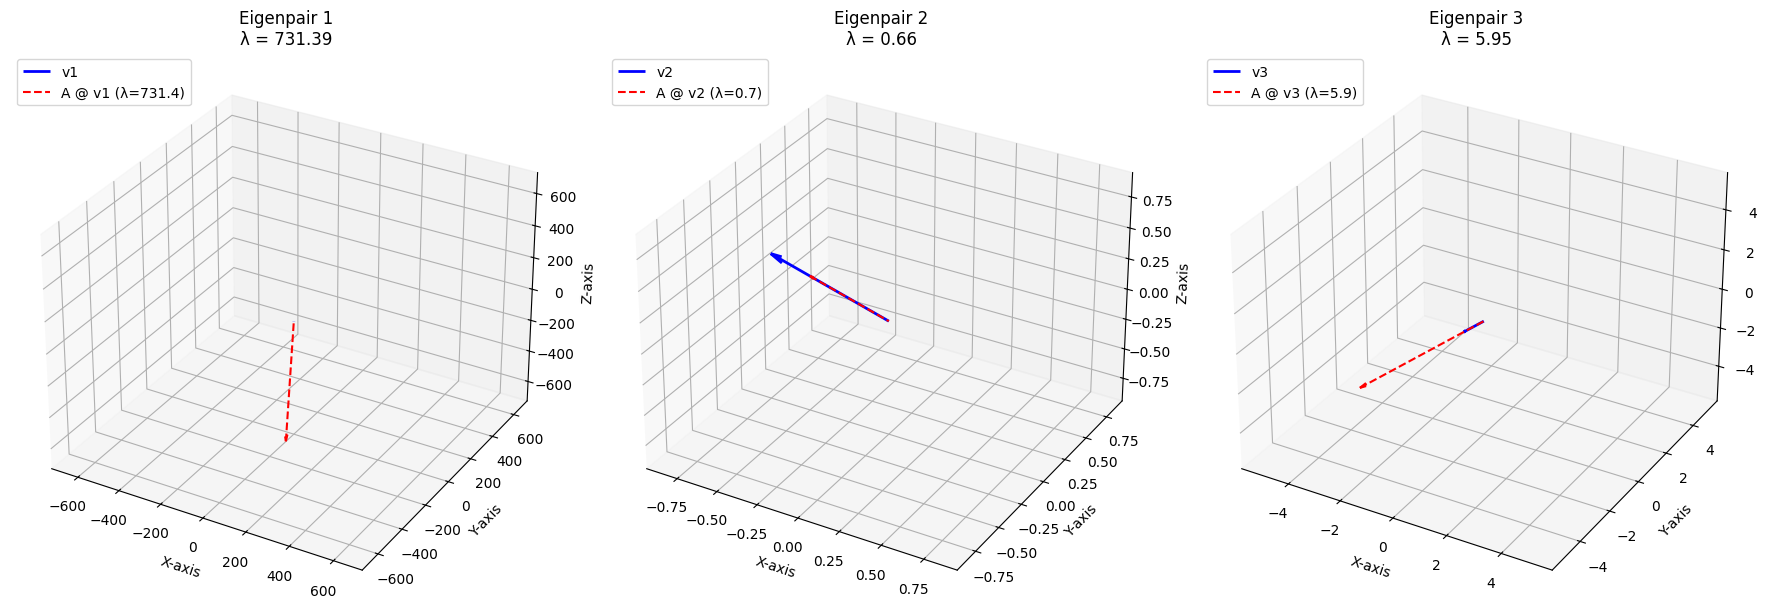

In [20]:
# Set a 3x3 matrix
A = np.array([[1, 1, 1], [2, 8, 64], [3, 27, 729]], dtype=float)

# Set the eigenvalues and eigenvector values.
eigenval, eigenvec = np.linalg.eig(A)

# Print out eigenvalues and eigenvectors.
print(f"\nMatrix A has the following eigenvalues and eigenvectors.")
print(f"{A}")
print(f"Eigenvalues = {eigenval}")
print(f"Eigenvectors = \n{eigenvec}")

for i, lam in enumerate(eigenval):
    vec = eigenvec[:, i]
    residual = A @ vec - lam * vec
    print(f"\nEigenpair {i+1}")
    print("lambda =", lam)
    print("v =", vec)
    print("M @ v =", A @ vec)
    print("lambda * v =", lam * vec)
    print("residual norm =", np.linalg.norm(residual))

# 3D Visualizations of Eigenpairs
fig = plt.figure(figsize=(18, 6))

for i, lam in enumerate(eigenval):
    vec = eigenvec[:, i]
    Av = A @ vec

    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    o = [0, 0, 0]

    # Plot original eigenvector (v) in Blue
    ax.quiver(*o, *vec, color='blue', label=f'v{i+1}', linewidth=2, arrow_length_ratio=0.1)

    # Plot transformed vector (A @ v) in Red (dashed/thinner so both are visible)
    ax.quiver(*o, *Av, color='red', label=f'A @ v{i+1} (λ={lam:.1f})', linewidth=1.5, linestyle='--', arrow_length_ratio=0.05)

    # Dynamic axis scaling based on vector size
    max_range = max(np.max(np.abs(vec)), np.max(np.abs(Av)))
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])

    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.set_zlabel('Z-axis')
    ax.set_title(f"Eigenpair {i+1}\nλ = {lam:.2f}")
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()